IIR 2D by optimization

---

Kishore Kumar Tarafdar, 25 May 2025

        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-06-19 08:05:05.970457: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750300505.995322 4183894 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750300506.002510 4183894 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-19 08:05:06.025650: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    # '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from DWT1DFB import DWT1D, IDWT1D
# from DWT2DFB import DWT2D, IDWT2D
import matplotlib.pyplot as plt

2025-05-24 22:02:06.562632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748104326.583081   36719 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748104326.589366   36719 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-24 22:02:06.610762: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3
3 Physical GPUs available 
Selected 1 Logical GPU with 32 GB memory limit


I0000 00:00:1748104328.659830   36719 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 32768 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


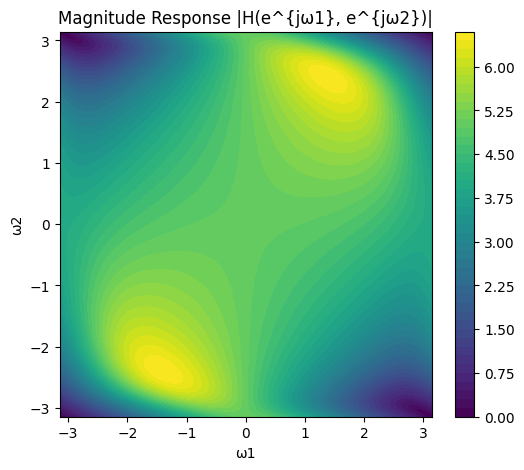

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Example coefficients
b = np.array([[1, 2], [3, 4]])
a = np.array([[1, 0.5], [0.2, 0.3]])

# Frequency grid
w1 = np.linspace(-np.pi, np.pi, 256)
w2 = np.linspace(-np.pi, np.pi, 256)
W1, W2 = np.meshgrid(w1, w2)

# Compute z1, z2
z1 = np.exp(1j * W1)
z2 = np.exp(1j * W2)

# Compute B and A
B = (b[0,0] + b[0,1]/z2 + b[1,0]/z1 + b[1,1]/(z1*z2))
A = (a[0,0] + a[0,1]/z2 + a[1,0]/z1 + a[1,1]/(z1*z2))
H = B / A

# Plot magnitude response
plt.figure(figsize=(6,5))
plt.contourf(w1, w2, np.abs(H), levels=50)
plt.title("Magnitude Response |H(e^{jω1}, e^{jω2})|")
plt.xlabel('ω1')
plt.ylabel('ω2')
plt.colorbar()
plt.show()


        2D shifts of x[n1,n2]

        
$(\text{batch, N, N, inchannel}) \rightarrow (\text{batch, N, N, inchannel, outchannel, (Delays+1)}^2)$

In [94]:
import tensorflow as tf

def circular_shift_x_2d(x, delays, out_channels):
    """
    x: Tensor of shape (batch, N, N, channels)
    delays: int, number of delays in each dimension
    out_channels: int, number of output channels (identical copies)
    
    Returns:
        Tensor of shape (batch, N, N, channels, (D+1)**2, out_channels)
    """
    # batch, N, _, channels = tf.unstack(tf.shape(x))
    batch, N, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[3]
    # out_channels = self.filters

    # Create grid of shifts: shape ((D+1)**2, 2)
    shifts = tf.range(delays + 1)
    shift_grid = tf.stack(tf.meshgrid(shifts, shifts, indexing="ij"), axis=-1)  # (D+1, D+1, 2)
    shift_grid = tf.reshape(shift_grid, [-1, 2])  # (num_shifts, 2)

    # Broadcast input x to (num_shifts, batch, N, N, channels)
    x_broadcasted = tf.expand_dims(x, axis=0)
    x_broadcasted = tf.repeat(x_broadcasted, repeats=tf.shape(shift_grid)[0], axis=0)

    # Roll each slice using vectorized shift
    def single_roll(args):
        x_i, shift = args
        return tf.roll(x_i, shift=[-shift[0], -shift[1]], axis=[1, 2])

    rolled = tf.map_fn(single_roll, (x_broadcasted, shift_grid), fn_output_signature=tf.TensorSpec(shape=(None, None, None, None), dtype=x.dtype))

    # rolled shape: (num_shifts, batch, N, N, channels) → transpose to (batch, N, N, channels, num_shifts)
    rolled = tf.transpose(rolled, perm=[1, 2, 3, 4, 0])

    # Expand and tile to (batch, N, N, channels, num_shifts, out_channels)
    rolled = tf.expand_dims(rolled, axis=-1)
    rolled = tf.tile(rolled, [1, 1, 1, 1, 1, out_channels])

    return rolled


In [96]:
x = tf.random.normal((2, 3, 3, 1))
delays = 1
out_channels = 10

x_shifted = circular_shift_x_2d(x, delays, out_channels)
print(x_shifted.shape)  # (8, 32, 32, 4, 9, 3)

(2, 3, 3, 1, 4, 10)


In [93]:
x.shape

TensorShape([2, 3, 3, 3])

In [ ]:
# from sympy import Matrix

        2D circular shifts of y[n1,n2]
        
        
$(\text{batch, N, N, inchannel, outchannel}) \rightarrow (\text{batch, N, N, inchannel, outchannel, (Delays+1)}^2)$

In [ ]:
import tensorflow as tf

def circular_shift_y_2d(y, delays):
    """
    y: Tensor of shape (batch, N, N, channels, out_channels)
    delays: int, number of delays in each dimension

    Returns:
        Tensor of shape (batch, N, N, channels, (D+1)**2, out_channels)
    """
    batch, N, _, channels, out_channels = tf.unstack(tf.shape(y))
    

    # Create grid of shifts: shape ((D+1)**2, 2)
    shifts = tf.range(delays + 1)
    shift_grid = tf.stack(tf.meshgrid(shifts, shifts, indexing="ij"), axis=-1)  # (D+1, D+1, 2)
    shift_grid = tf.reshape(shift_grid, [-1, 2])  # (num_shifts, 2)

    # Broadcast y to shape (num_shifts, batch, N, N, channels, out_channels)
    y_broadcasted = tf.expand_dims(y, axis=0)
    y_broadcasted = tf.repeat(y_broadcasted, repeats=tf.shape(shift_grid)[0], axis=0)

    # Roll each slice using vectorized shift
    def single_roll(args):
        y_i, shift = args
        return tf.roll(y_i, shift=[-shift[0], -shift[1]], axis=[1, 2])

    rolled = tf.map_fn(
        single_roll,
        (y_broadcasted, shift_grid),
        fn_output_signature=tf.TensorSpec(shape=(None, None, None, None, None), dtype=y.dtype)
    )

    # rolled shape: (num_shifts, batch, N, N, channels, out_channels)
    # → transpose to (batch, N, N, channels, num_shifts, out_channels)
    rolled = tf.transpose(rolled, perm=[1, 2, 3, 4, 0, 5])

    return rolled


In [7]:
y = tf.random.normal((2, 4, 4, 5, 3))
delays = 2
# out_channels = 10
#5. Initialize y of shape (batch, N, N, channels, out_channels)
#6. Prepare circularly shifted y with delays, Y of (batch, N, N, channels, (D+1)^{\ensuremath{2}}, out_channels)

y_shifted = circular_shift_y_2d(y, delays)
print(y.shape, "->", y_shifted.shape)  # (8, 32, 32, 4, 9, 3)

(2, 4, 4, 5, 3) -> (2, 4, 4, 5, 9, 3)


In [94]:
bs, inch, outch = 0, 0, 2
print(f"y:=\n{y[bs,:,:,inch, outch]}\n\n")

for dela in range(y_shifted.shape[-2]):
    print(f"\nDelay {dela}: \n{y_shifted[bs, :, :, inch, dela, outch]}")


y:=
[[-0.47793463  2.368154    0.02954458  1.3579674 ]
 [ 0.9737256  -0.4127534   0.24989767 -0.6689771 ]
 [ 1.0997419  -0.7924142   0.00435362  2.1039052 ]
 [ 0.57392746 -0.88390076 -1.610216    1.2190082 ]]



Delay 0: 
[[-0.47793463  2.368154    0.02954458  1.3579674 ]
 [ 0.9737256  -0.4127534   0.24989767 -0.6689771 ]
 [ 1.0997419  -0.7924142   0.00435362  2.1039052 ]
 [ 0.57392746 -0.88390076 -1.610216    1.2190082 ]]

Delay 1: 
[[ 2.368154    0.02954458  1.3579674  -0.47793463]
 [-0.4127534   0.24989767 -0.6689771   0.9737256 ]
 [-0.7924142   0.00435362  2.1039052   1.0997419 ]
 [-0.88390076 -1.610216    1.2190082   0.57392746]]

Delay 2: 
[[ 0.02954458  1.3579674  -0.47793463  2.368154  ]
 [ 0.24989767 -0.6689771   0.9737256  -0.4127534 ]
 [ 0.00435362  2.1039052   1.0997419  -0.7924142 ]
 [-1.610216    1.2190082   0.57392746 -0.88390076]]

Delay 3: 
[[ 0.9737256  -0.4127534   0.24989767 -0.6689771 ]
 [ 1.0997419  -0.7924142   0.00435362  2.1039052 ]
 [ 0.57392746 -0.88390076 -1

# IIR 2D layer

         IIR 2D layer final

        circulal shift x
        (batch_size, N, inchannels) -> (batch_size, N, inchannels, Delays+1, outchannels)

In [ ]:
## OK general IIR 2D layer
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class Positive(tf.keras.constraints.Constraint):
    """Makes sure non negative by clipping -ve values to 0"""
    def __call__(self, w):
        return tf.maximum(w, 0.0)  # Clip negative values to 0
        # return tf.nn.relu(w)
        return w

    def get_config(self):
        return {}  # No parameters to serialize

# class No(Constraint):
#     def __call__(self, w):
#         # return tf.maximum(w, 0.0)  # Clip negative values to 0
#         # return tf.nn.relu(w)
#         return w

@tf.keras.utils.register_keras_serializable()
class IIR2D(tf.keras.layers.Layer):
    """IIRTF: Fast trainable multidimensional IIR filter layers in TensorFlow.
    Copyright (C) 2025 Kishore Kumar Tarafdar

    This program is free software: you can redistribute it and/or modify
    it under the terms of the GNU General Public License as published by
    the Free Software Foundation, either version 3 of the License, or
    (at your option) any later version.

    This program is distributed in the hope that it will be useful,
    but WITHOUT ANY WARRANTY; without even the implied warranty of
    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
    GNU General Public License for more details.

    You should have received a copy of the GNU General Public License
    along with this program.  If not, see <https://www.gnu.org/licenses/>.

    IIR 2D Layer --kkt 24-05-2025"""
    def __init__(self, Delays:int, filters:int, tolerance=1e-6, max_steps=5000, local_lr=0.001, **kwargs):
        super().__init__(**kwargs)
        self.Delays = Delays
        self.filters = filters ## number of out channels
        self.tolerance = tolerance
        self.max_steps = max_steps
        self.local_lr = local_lr
        # Define optimizer (can be class attribute if needed)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=self.local_lr)

    def build(self, input_shape):
        self.N = input_shape[1]
        self.channels = input_shape[-1]

        # Create grid of shifts: shape ((D+1)**2, 2)
        shifts = tf.range(self.Delays + 1)
        shift_grid = tf.stack(tf.meshgrid(shifts, shifts, indexing="ij"), axis=-1)  # (D+1, D+1, 2)
        self.shift_grid = tf.reshape(shift_grid, [-1, 2])  # (num_shifts, 2)
        
        ## IIR feed forward coeffs
        self.b = self.add_weight(
            shape=(self.channels, int((self.Delays + 1)**2), self.filters), 
            initializer=tf.keras.initializers.RandomUniform(minval=0.0, maxval=0.1), 
            trainable=True, 
            name="b_coeffs",
            constraint=Positive() ## no constraint
        )
        ## IIR feed back coeffs
        self.a = self.add_weight(
            shape=(self.channels, int((self.Delays + 1)**2-1), self.filters), 
            initializer=tf.keras.initializers.RandomUniform(minval=0.0, maxval=0.1), 
            trainable=True, 
            name="a_coeffs",
            constraint=Positive() ## constraint >0 for STABLE FILTER
        )
        # ## Setting a0=1 in feedback coeffs
        # a0s = tf.ones((self.channels, 1, self.filters))
        # self.A = tf.concat([a0s, self.a], axis=-2)  # shape: (channels, Delays+1)

        # self.output_shape = (input_shape[0],input_shape[1], input_shape[2], self.filters) 

       
    # @tf.function(jit_compile=False)  # Disable XLA for debugging
    def call(self, x):
        ## Setting a0=1 in feedback coeffs
        a0s = tf.ones((self.channels, 1, self.filters))
        A = tf.concat([a0s, self.a], axis=-2)  # shape: (channels, Delays+1)
        
        ## initializing IIR filter or layer output y
        # y = tf.identity(x)  # start from input
        # y = tf.zeros_like(x)
        y = tf.random.uniform(
            shape=(tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3],  self.filters),
            minval=0,
            maxval=1
            )

        ## Creating shifted tensor: [x[n], x[n-1], ... , x[n-D]] 
        Xshifted = self.__circularshift_x2d(x)  # Precompute once
        # self.Xshifted = Xshifted

        ## Local optimization loss
        def compute_residual(y_var):
            """Compute Residual |AX-BY| for local optimization"""
            Yshifted = self.__circularshift_y2d(y_var)
            # print('+',Xshifted.shape, self.b.shape)
            # print('+',Yshifted.shape, self.a.shape)
            BX = tf.einsum('bnmcdo,cdo->bnmo', Xshifted, self.b)
            AY = tf.einsum('bnmcdo,cdo->bnmo', Yshifted, A)
            
            residual = BX - AY
            # loss = tf.reduce_sum(residual) # unstable filters
            # loss = tf.reduce_sum(tf.abs(residual)) #better
            loss = tf.reduce_sum(tf.square(residual)) #better
            return loss, residual

        # Optimization loop------
        i = tf.constant(0)
        loss_init, _ = compute_residual(y)

        # i = tf.constant(0, dtype=tf.int32)
        # loss_init = tf.constant(float('inf'), dtype=x.dtype)

        def cond(i, y_var, loss):
            # print(loss.numpy(), self.tolerance, (loss > self.tolerance).numpy())
            return tf.logical_and(loss > self.tolerance, i < self.max_steps)
        
        def body(i, y_var, loss):
            with tf.GradientTape() as tape:
                print(f'{i}', end=', ')
                tape.watch(y_var)
                loss, _ = compute_residual(y_var)
            grads = tape.gradient(loss, [y_var] + self.trainable_variables)
            dy = grads[0]
            # dvars = grads[1:]

            # Update y manually
            y_var = y_var - self.local_lr * dy
            return i + 1, y_var, loss

        i, y_opt, loss_final = tf.while_loop(
            cond, 
            body,
            loop_vars=[i, y, loss_init],
            # maximum_iterations=self.max_steps,  # Critical for XLA
            # shape_invariants=[
            #     i.shape,
            #     tf.TensorShape([None, self.N, self.channels]),  # Batch dimension can vary
            #     loss_init.shape
            # ]
            # maximum_iterations=self.max_steps
            # maximum_iterations=None
        )
        ## END local optimization----------               
        y = tf.einsum('bnmco->bnmo', y_opt)
        # print('y shape' ,y.shape)
        # y = tf.expand_dims(, axis=-1)
        return y

    def __circularshift_x2d(self, x):
        """
        x: Tensor of shape (batch, N, N, channels)
        delays D: int, number of delays in each dimension
        out_channels: int, number of output channels (identical copies)
        
        Returns:
            Tensor of shape (batch, N, N, channels, (D+1)**2, out_channels)
        """
        # batch, N, _, channels = tf.unstack(tf.shape(x))
        batch, N, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[3]
        # out_channels = self.filters
        # num_shifts = tf.shape(self.shift_grid)[0]  # (D+1)^2

        # # Create grid of shifts: shape ((D+1)**2, 2)
        # shifts = tf.range(self.Delays + 1)
        # shift_grid = tf.stack(tf.meshgrid(shifts, shifts, indexing="ij"), axis=-1)  # (D+1, D+1, 2)
        # self.shift_grid = tf.reshape(shift_grid, [-1, 2])  # (num_shifts, 2)

        # Broadcast input x to (num_shifts, batch, N, N, channels)
        x_broadcasted = tf.expand_dims(x, axis=0)
        x_broadcasted = tf.repeat(x_broadcasted, repeats=tf.shape(self.shift_grid)[0], axis=0)

        # Roll each slice using vectorized shift
        def single_roll(args):
            x_i, shift = args
            return tf.roll(x_i, shift=[-shift[0], -shift[1]], axis=[1, 2])

        rolled = tf.map_fn(
            single_roll, 
            (x_broadcasted, self.shift_grid), 
            fn_output_signature=tf.TensorSpec(shape=(None, None, None, None), dtype=x.dtype))

        # rolled shape: (num_shifts, batch, N, N, channels) → transpose to (batch, N, N, channels, num_shifts)
        rolled = tf.transpose(rolled, perm=[1, 2, 3, 4, 0])

        # Expand and tile to (batch, N, N, channels, num_shifts, out_channels)
        rolled = tf.expand_dims(rolled, axis=-1)
        rolled = tf.tile(rolled, [1, 1, 1, 1, 1, self.filters])

        return rolled

    def __circularshift_y2d(self, y):
        """
        y: Tensor of shape (batch, N, N, channels, out_channels)
        delays: int, number of delays in each dimension

        Returns:
            Tensor of shape (batch, N, N, channels, (D+1)**2, out_channels)
        """
        # batch, N, _, channels,  = tf.unstack(tf.shape(y))
        # batch, N, _, channels, out_channels = tf.shape(y)
        batch, N, channels, out_channels = tf.shape(y)[0], tf.shape(y)[1], tf.shape(y)[-2], tf.shape(y)[-1]

        # Create grid of shifts: shape ((D+1)**2, 2)
        # shifts = tf.range(delays + 1)
        # shift_grid = tf.stack(tf.meshgrid(shifts, shifts, indexing="ij"), axis=-1)  # (D+1, D+1, 2)
        # shift_grid = tf.reshape(shift_grid, [-1, 2])  # (num_shifts, 2)

        # Broadcast y to shape (num_shifts, batch, N, N, channels, out_channels)
        y_broadcasted = tf.expand_dims(y, axis=0)
        y_broadcasted = tf.repeat(y_broadcasted, repeats=tf.shape(self.shift_grid)[0], axis=0)

        # Roll each slice using vectorized shift
        def single_roll(args):
            y_i, shift = args
            return tf.roll(y_i, shift=[-shift[0], -shift[1]], axis=[1, 2])

        rolled = tf.map_fn(
            single_roll,
            (y_broadcasted, self.shift_grid),
            fn_output_signature=tf.TensorSpec(shape=(None, None, None, None, None), dtype=y.dtype)
        )

        # rolled shape: (num_shifts, batch, N, N, channels, out_channels)
        # → transpose to (batch, N, N, channels, num_shifts, out_channels)
        rolled = tf.transpose(rolled, perm=[1, 2, 3, 4, 0, 5])

        return rolled

    def get_config(self):
        config = super().get_config()
        config.update({
            'Delays': self.Delays,
            'filters': self.filters,
            'tolerance': self.tolerance,
            'max_steps': self.max_steps,
            'local_lr': self.local_lr,
        })
        return config



if __name__=='__main__':
    # Example usage:
    batch_size = 10
    N = 128
    channels = 12
    filters = 3
    # x = tf.random.normal((batch_size, N, channels))
    x = tf.random.uniform(shape=(batch_size, N, N, channels), minval=0, maxval=1)

    Delays = 1
    layer = IIR2D(Delays=Delays, filters=filters, max_steps=5000)#N-1)
    print(x.shape)
    out = layer(x)
    # # out = layer(out)
    # print("Residual output shape:", out.shape)
    # print(out.numpy())


    ##Example 
    input_shape = (128, 128, 12)
    inputs = tf.keras.Input(shape=input_shape)
    outputs = IIR2D(Delays=3, filters=9)(inputs)
    outputs = IIR2D(Delays=3, filters=3)(outputs)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.summary()
    del input_shape, inputs, outputs, model


(10, 128, 128, 12)
0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 2

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ iir2d_11 (IIR2D)                │ (None, 128, 128, 9)    │         3,348 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ iir2d_12 (IIR2D)                │ (None, 128, 128, 3)    │           837 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,185 (16.35 KB)

 Trainable params: 4,185 (16.35 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
out.shape

TensorShape([10, 128, 128, 3])

In [19]:
input_shape = (128, 128, 12)
inputs = tf.keras.Input(shape=input_shape)
outputs = IIR2D(Delays=3, filters=9)(inputs)
outputs = IIR2D(Delays=3, filters=3)(outputs)
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()
del input_shape, inputs, outputs, model


Tensor("while/Placeholder:0", shape=(), dtype=int32), Tensor("while/Placeholder:0", shape=(), dtype=int32), 

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ iir2d_6 (IIR2D)                 │ (None, 128, 128, 9)    │         3,348 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ iir2d_7 (IIR2D)                 │ (None, 128, 128, 3)    │           837 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,185 (16.35 KB)

 Trainable params: 4,185 (16.35 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
layer.b.shape, layer.a.shape #layer.Xshifted.shape

(TensorShape([12, 4, 3]), TensorShape([12, 3, 3]))

In [21]:
out.shape

TensorShape([10, 128, 128, 3])

        plot

In [22]:
out.shape, layer.a.shape, layer.b.shape, layer.b

(TensorShape([10, 128, 128, 3]),
 TensorShape([12, 3, 3]),
 TensorShape([12, 4, 3]),
 <KerasVariable shape=(12, 4, 3), dtype=float32, path=iir2d_5/b_coeffs>)

In [23]:
# for i in range(out.shape[-1]):
#     print(out[0,:,i].numpy())

In [25]:
# ch = 1
# filt = 0

# btmp = layer.b[ch,:,filt].numpy()
# atmp = layer.a[ch,:,filt].numpy()
# btmp, atmp
# # plot_pole_zero(btmp, atmp)

In [20]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Defining a model with IIR2D layer and Training

        Define an model with the IIR2D layer and check

In [27]:
# Dummy data
batch_size, N, channels, filters = 10, 32, 9, 3
x_train = tf.random.normal((batch_size, N, N, channels))
y_dummy = tf.random.normal((batch_size, N, N, filters))
# y_dummy = tf.zeros_like(x_train)
x_train.shape, y_dummy.shape, x_train.dtype, y_dummy.dtype
# compile model
# model = Layer1D(D=Delays,max_steps=100)#N-1)
# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01))
# Build and compile model
# layer = Layer1D(D=N-1)


# def model(input_shape):
#     inputs = tf.keras.Input(shape=input_shape)  # shape: (batch, N, channels)
#     x = Layer1D(D=100)(inputs)        # shape: (batch, N, channels)
#     outputs = tf.keras.layers.Dense(channels)(x)  # project back to same shape
#     return tf.keras.Model(inputs=inputs, outputs=outputs)


# # # Fit model for 2 epochs
# # model.fit(x=x_train, y=y_dummy, epochs=2, batch_size=10)

(TensorShape([10, 32, 32, 9]),
 TensorShape([10, 32, 32, 3]),
 tf.float32,
 tf.float32)

In [14]:
Delays, filters

(1, 3)

In [28]:
def model(
    input_shape=(128, 128, 1),
    # Delays=Delays,
    # filters=filters
    # loss = 'binary_crossentropy',
    # optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    # compile=True
    ):

    inputs = tf.keras.layers.Input(input_shape)
    q = IIR2D(Delays=1, filters=6, tolerance=1e-6, max_steps=100, local_lr=0.001)(inputs)
    # print('q', q.shape)
    q = IIR2D(Delays=1, filters=3, tolerance=1e-6, max_steps=100, local_lr=0.001)(q)
    
    
    outputs = q  
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

    # if compile==True:
    #     # model = tf.keras.Model(inputs=[inputs], outputs=[x])
    #     # generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
    #     # model.compile(optimizer=generator_optimizer, loss=generator_loss)
       
    #     model.compile(optimizer=optimizer, loss=loss)
    #     return model
    #     #
    # else: 
    #     return model


m = model(input_shape=(N, N, channels))#, Delays=Delays, filters=filters)  # (N=20, channels=16)
# m.compile(optimizer='adam', loss='mse')

# model = LayerModel(layer)
m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', jit_compile=False)  # Disable XLA for debugging)
m.summary()



Tensor("while/Placeholder:0", shape=(), dtype=int32), Tensor("while/Placeholder:0", shape=(), dtype=int32), 

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 9)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ iir2d_8 (IIR2D)                 │ (None, 32, 32, 6)      │           378 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ iir2d_9 (IIR2D)                 │ (None, 32, 32, 3)      │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504 (1.97 KB)

 Trainable params: 504 (1.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Run for 2 epochs
m.fit(x=x_train, y=y_dummy, epochs=3, batch_size=batch_size)

Epoch 1/10
Tensor("functional_3_1/iir2d_8_1/while/Placeholder:0", shape=(), dtype=int32), 

/data1/kishoretarafdar/miniforge3/envs/tf218/lib/python3.12/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_9']. Received: the structure of inputs=*
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 67s 67s/step - loss: 1.9899"functional_3_1/iir2d_8_1/while/Placeholder:0", shape=(), dtype=int32), Tensor("functional_3_1/iir2d_9_1/while/Placeholder:0", shape=(), dtype=int32),
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 62s 62s/step - loss: 1.7142
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 62s 62s/step - loss: 1.5248
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 62s 62s/step - loss: 1.4003
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 63s 63s/step - loss: 1.3112
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 63s 63s/step - loss: 1.2427
Epoch 7/10


KeyboardInterrupt: 

        Troubleshoot gradient update

In [52]:
with tf.GradientTape() as tape:
    y_pred = m(x_train)
    loss = tf.reduce_mean(tf.square(y_pred - y_dummy))

grads = tape.gradient(loss, m.trainable_variables)
for var, g in zip(m.trainable_variables, grads):
    print(f"{var.name}: {'✅ OK' if g is not None else '❌ No Grad'}")

for var, grad in zip(m.trainable_variables, grad):
    if grad is not None:
        print(f"{var.name}: mean gradient {tf.reduce_mean(tf.abs(grad)):.6f}")
    else:
        print(f"{var.name}: NO GRADIENTS")


0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, b_coeffs: ✅ OK
a_coeffs: ✅ OK
b_coeffs: ✅ OK
a_coeffs: ✅ OK
b_coeffs: mean gradient 20.231028
a_coeffs: mean gradient 18.494989
b_coeffs: mean gradient 20.688673
a_coeffs: mean gradient 19.031796


In [26]:
m.predict(x_train).shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step, dtype=int32), Tensor("functional_1_1/iir_layer1d_4_1/while/Placeholder:0", shape=(), dtype=int32),


(10, 128, 3)

In [27]:
[_.shape for _ in m.layers[1].get_weights()]
# [_.shape for _ in m.layers[2].get_weights()]
# [_.shape for _ in m.layers[3].get_weights()]


[(12, 41, 10), (12, 40, 10)]

In [28]:
[_.shape for _ in m.weights]

[TensorShape([12, 41, 10]),
 TensorShape([12, 40, 10]),
 TensorShape([10, 41, 3]),
 TensorShape([10, 40, 3])]

In [29]:
m.weights[0].numpy()
m.weights[1].numpy().shape

(12, 40, 10)

In [30]:
b = m.weights[0].numpy()
a = m.weights[1].numpy()
# b = m.weights[2].numpy()
# a = m.weights[3].numpy()

a0s = tf.ones((channels, 1, filters))
a.shape, a0s.shape
# a = tf.concat([a0s, a], axis=-2)  # shape: (channels, Delays+1, outchannels)
# a0s.shape, a.shape, b.shape

((12, 40, 10), TensorShape([12, 1, 3]))

In [53]:
# # for j in range(bs):
# for filt in range(filters):
#     for ch in range(channels):
#         # Plot for first batch and first channel
#         b_example = b[ch,:,filt]
#         a_example = a[ch,:,filt]
#         print(f"filter: {filt}, channel: {ch},\ncoeffs b: {b_example}\ncoeffs a: {a_example}")
#         plot_pole_zero(b_example, a_example)


In [54]:
# for filt in range(filters):
#     for ch in range(channels):
#         # Plot for first batch and first channel
#         b_example = b[ch,:,filt]
#         a_example = a[ch,:,filt]
#         print(f"filter: {filt}, channel: {ch},\ncoeffs b: {b_example}\ncoeffs a: {a_example}")
#         plot_frequency_response(b_example, a_example)